# Trabajo Práctico N° 4 - Métodos de Regularización y CART para Predicción de Pobreza
## Universidad de Buenos Aires - Facultad de Ciencias Económicas
## Taller de Programación - Grupo 10

---

### Objetivo

El presente trabajo práctico tiene como objetivo aplicar técnicas de **machine learning supervisado** para predecir si una persona es pobre utilizando características socioeconómicas y demográficas individuales provenientes de la Encuesta Permanente de Hogares (EPH) del INDEC.

Se implementarán y compararán dos modelos de regularización de los coeficientes obtenidos por regresión:
- **Ridge**: aplica penalidad no estricta.
- **LASSO**: aplica penalidad estricta, selecciona predictores.

Se contrastarán luego los resultados obtenidos con la predicción por CART:
- **Árboles de decisión**: método no paramétrico de función de densidad condicional. 

### Estructura del análisis

**A. Modelo de Regresion Logistica con Regularización: Ridge y LASSO:** visualización de la grilla de coeficientes y selección de penalidad lambda por cross validation. 

**B. Árboles de decisión:** Estimación, interpretación de coeficientes y visualización.

**C. Comparación entre métodos:** performance predictiva, interpretabilidad de los resultados y aplicación de políticas públicas.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from estilo_graficos import UBA_FCE_COLORS, configurar_estilo_grafico, formatear_ejes, forzar_y_cero

COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

## A. Modelo de Regresion Logistica con Regularización

Se trabaja con datos de la EPH 2025 del Gran Buenos Aires, utilizando la base de trabajo generada en el TP previo.

**Estrategia de validación replicada del TP3:**
- División train/test: 70% entrenamiento - 30% prueba
- Estratificación por variable objetivo (POBRE) para mantener proporción de pobres en ambos conjuntos
- Random state = 444 para reproducibilidad (según consigna del TP)

**Variables predictoras seleccionadas:**
- `CH04`: Sexo (1=Varón, 2=Mujer)
- `CH06`: Edad en años cumplidos
- `NIVEL_ED`: Nivel educativo alcanzado. Categoría base: primaria incompleta. Niveles pares: completos/ niveles impares: incompletos.
- `ESTADO`: Condición de actividad (Ocupado/Desocupado/Inactivo). Categoría base: ocupado. 2: desocupado/ 3: inactivo/ 4: menor.
- `HORASTRAB`: Horas trabajadas por semana.
- `CAT_OCUP`: Categoría ocupacional. Categoría base: desocupado (no responde). 1: patrón/ 2: cuentapropista/ 3: empleado/ 4 sin remuneración/ 9: Ns-Nr.

In [43]:
# Cargar base de trabajo procesada (contiene solo 2025)
df_trabajo= pd.read_csv("../TP3/datos/base_tp3_trabajo.csv")            
        
display(df_trabajo.head())

,CH06,HORASTRAB,POBRE,CH04_2,NIVEL_ED_2,NIVEL_ED_3,NIVEL_ED_4,NIVEL_ED_5,NIVEL_ED_6,NIVEL_ED_7,ESTADO_2,ESTADO_3,ESTADO_4,CAT_OCUP_1.0,CAT_OCUP_2.0,CAT_OCUP_3.0,CAT_OCUP_4.0,CAT_OCUP_9.0
0,30.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,82.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,34.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,32.0,0.0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,10.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [44]:
# Renombrar Ch04_2 a Sexo y CH06 a Edad para simplificar visualización de las etiquetas
df_trabajo = df_trabajo.rename(columns={'CH04_2': 'Sexo', 'CH06': 'Edad'})

In [45]:
# Réplica de la división train/test del TP3

X = df_trabajo.drop('POBRE', axis=1)
y = df_trabajo['POBRE']

# División train/test según consigna: 70% train, 30% test, random_state=444, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444, stratify=y)

print(f"\n{'='*70}")
print(f"DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)")
print(f"{'='*70}")
print(f"Train: {len(X_train):,} obs ({len(X_train)/len(X)*100:.1f}%) - Pobres: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test):,} obs ({len(X_test)/len(X)*100:.1f}%) - Pobres: {y_test.mean()*100:.1f}%")
print(f"Total features: {X_train.shape[1]}")


DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)
Train: 3,023 obs (70.0%) - Pobres: 31.5%
Test:  1,296 obs (30.0%) - Pobres: 31.4%
Total features: 17


**A.1) Visualización de posibles coefiecientes**

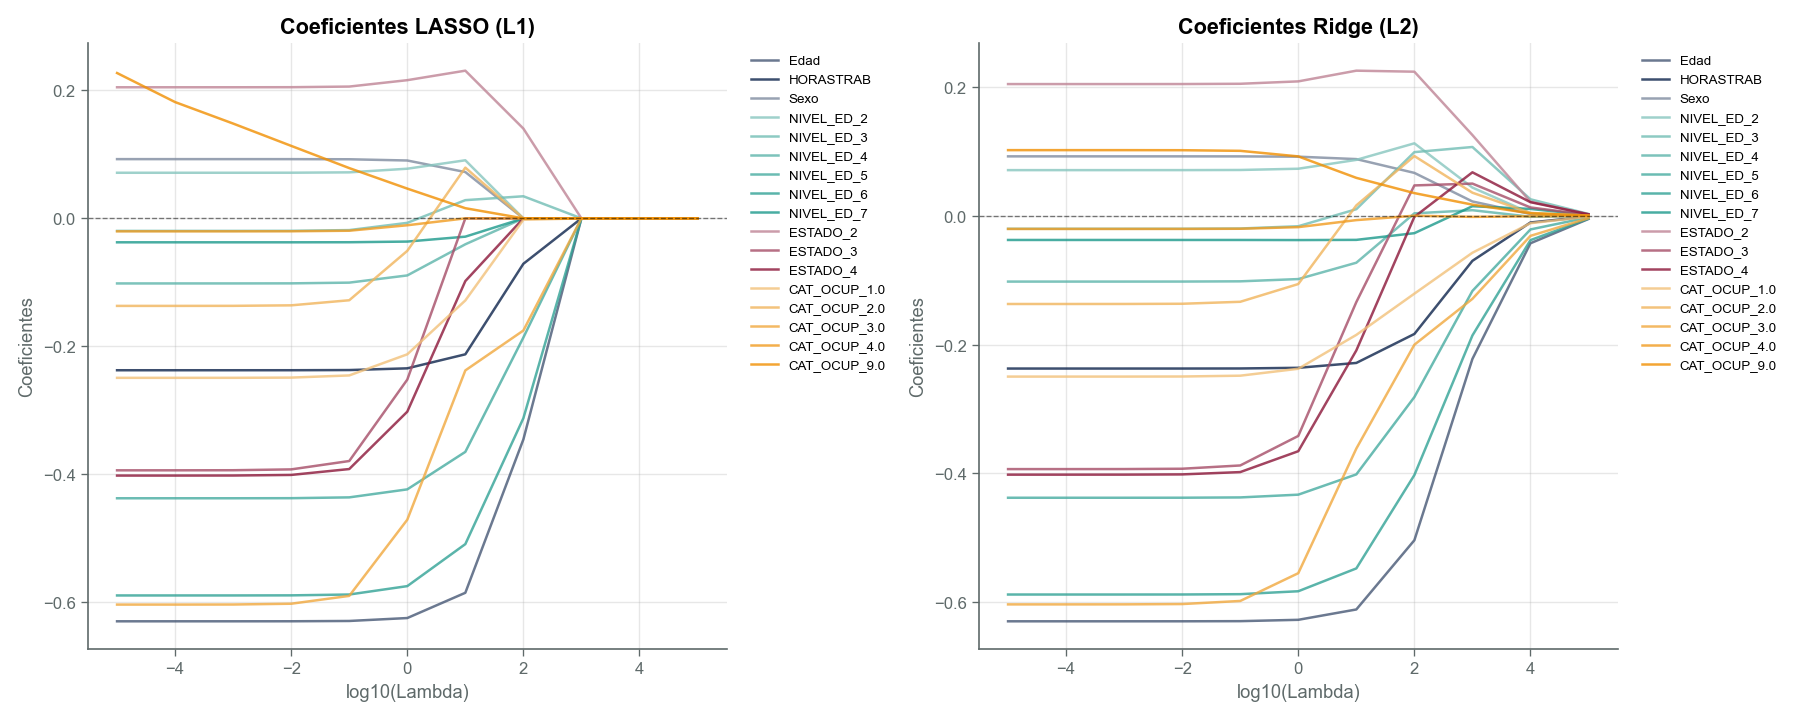

In [46]:
# Preparar los datos:
# Estandarizar (para posterior Regularización)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Definir la grilla de Lambda y C
# La consigna pide lambda = 10^n. Suponemos n entre -5 y 5
n_values = range(-5, 6)
lambdas = [10**n for n in n_values]
Cs = [1/l for l in lambdas] # Scikit-learn usa C, que es 1/lambda

# Entrenar modelos y guardar coeficientes
coefs_lasso = []
coefs_ridge = []

for c in Cs:
    # LASSO (Penalty L1)
    # solver='liblinear' funciona bien para datasets pequeños/medianos con L1
    lasso = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    lasso.fit(X_std, y)
    coefs_lasso.append(lasso.coef_[0])
    
    # RIDGE (Penalty L2)
    ridge = LogisticRegression(penalty='l2', C=c, solver='lbfgs', random_state=42)
    ridge.fit(X_std, y)
    coefs_ridge.append(ridge.coef_[0])

# Definir paleta de colores por grupo de variables usando colores institucionales
import matplotlib.colors as mcolors

def generar_tonos(color_base, n_tonos):
    """Genera tonos progresivos a partir de un color base UBA-FCE"""
    rgb = mcolors.to_rgb(color_base)
    tonos = []
    for i in range(n_tonos):
        factor = 0.5 + (i * 0.5 / max(n_tonos - 1, 1))  # de 50% a 100% intensidad
        tono = tuple(min(1.0, c * factor + (1 - factor) * 0.95) for c in rgb)
        tonos.append(mcolors.to_hex(tono))
    return tonos

# Contar cuántas dummies hay por categoría
nivel_ed_vars = [col for col in X.columns if 'NIVEL_ED' in col]
estado_vars = [col for col in X.columns if 'ESTADO' in col]
cat_ocup_vars = [col for col in X.columns if 'CAT_OCUP' in col]

# Generar paletas basadas en colores institucionales
tonos_azul = generar_tonos(COLORES['azul_uba'], 3)  # Para Sexo, Edad, HORASTRAB
tonos_verde = generar_tonos(COLORES['verde_eco'], len(nivel_ed_vars))  # Para NIVEL_ED
tonos_bordo = generar_tonos(COLORES['bordo'], len(estado_vars))  # Para ESTADO
tonos_naranja = generar_tonos(COLORES['naranja'], len(cat_ocup_vars))  # Para CAT_OCUP

# Crear diccionario de colores por variable
colores_vars = {}
idx_nivel = 0
idx_estado = 0
idx_cat = 0

for col in X.columns:
    if col == 'Sexo':
        colores_vars[col] = tonos_azul[0]
    elif col == 'Edad':
        colores_vars[col] = tonos_azul[1]
    elif col == 'HORASTRAB':
        colores_vars[col] = tonos_azul[2]
    elif 'NIVEL_ED' in col:
        colores_vars[col] = tonos_verde[idx_nivel]
        idx_nivel += 1
    elif 'ESTADO' in col:
        colores_vars[col] = tonos_bordo[idx_estado]
        idx_estado += 1
    elif 'CAT_OCUP' in col:
        colores_vars[col] = tonos_naranja[idx_cat]
        idx_cat += 1
    else:
        colores_vars[col] = COLORES['gris']

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico LASSO
for i, col in enumerate(X.columns):
    ax[0].plot(np.log10(lambdas), [c[i] for c in coefs_lasso], 
               color=colores_vars[col], label=col, linewidth=1.5, alpha=0.8)
ax[0].set_xlabel('log10(Lambda)', fontsize=11)
ax[0].set_ylabel('Coeficientes', fontsize=11)
ax[0].set_title('Coeficientes LASSO (L1)', fontsize=13, fontweight='bold')
ax[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax[0].grid(True, alpha=0.3)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Gráfico Ridge
for i, col in enumerate(X.columns):
    ax[1].plot(np.log10(lambdas), [c[i] for c in coefs_ridge], 
               color=colores_vars[col], label=col, linewidth=1.5, alpha=0.8)
ax[1].set_xlabel('log10(Lambda)', fontsize=11)
ax[1].set_ylabel('Coeficientes', fontsize=11)
ax[1].set_title('Coeficientes Ridge (L2)', fontsize=13, fontweight='bold')
ax[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('graficos/ridge_lasso_coeficientes.png', dpi=300, bbox_inches='tight')
plt.show()

**NOTA:** Las dummies se presentan en distintos tonos del mismo color para facilitar interpretación. En el caso de categorías ordenadas, como nivel educativo, un tono más oscuro indica mayor nivel. Por su parte, las variables numéricas se ven tonos azules.

**Interpretación del Gráfico LASSO (Izquierda)**

Lo más distintivo de LASSO (penalidad L1) es su capacidad de Selección de Variables.
El efecto "cero exacto": las líneas de colores no solo se achican, sino que golpean el 0 y se quedan ahí. Matemáticamente, LASSO fuerza a que los coeficientes de las variables menos importantes sean exactamente cero.

A medida que aumenta $\lambda$ (hacia la derecha), el modelo empieza a "apagar" variables. Las líneas que caen a cero rápidamente (en $\lambda$ bajos) corresponden a variables que no aportan mucha información para predecir pobreza o que son redundantes.

Las líneas que "sobreviven" más tiempo (se mantienen distintas de cero hacia la derecha) son los predictores más fuertes.

Conclusión: LASSO entrega un modelo más simple eliminando ruido.

**Interpretación del Gráfico Ridge (Derecha)**

Ridge (penalidad L2) funciona distinto; su propiedad principal es la contracción suave.

El efecto Asintótico: las líneas se curvan suavemente hacia el 0, pero nunca lo tocan realmente (o tardan muchísimo más).

Ridge nunca elimina variables. Incluso con penalizaciones altas, sigue usando toda la información disponible, solo que reduce la magnitud de los coeficientes para evitar que una sola variable domine excesivamente.

Esto es útil para reducir la varianza sin perder información, pero no simplifica la interpretación del modelo.

**Conclusión**

En el gráfico de LASSO, observamos que a medida que aumenta el parámetro de penalización $\lambda$, los coeficientes de varias variables se reducen exactamente a cero. 

Esto confirma la propiedad de selección de variables de la regularización L1, donde el modelo descarta predictores menos relevantes, generando una solución simplificada.

Por el contrario, en el gráfico de Ridge, los coeficientes convergen asintóticamente a cero pero no se anulan. La penalización L2 reduce la magnitud de los coeficientes (shrinkage) para controlar la varianza y la multicolinealidad, pero mantiene todas las variables en el modelo final.

**A.2) Penalidad óptima por cross validation**

Entrenando LASSO con Cross-Validation...
Entrenando RIDGE con Cross-Validation...
Entrenando RIDGE con Cross-Validation...

Mejor Lambda para LASSO: 0.1
Mejor Lambda para Ridge: 10.0

Mejor Lambda para LASSO: 0.1
Mejor Lambda para Ridge: 10.0


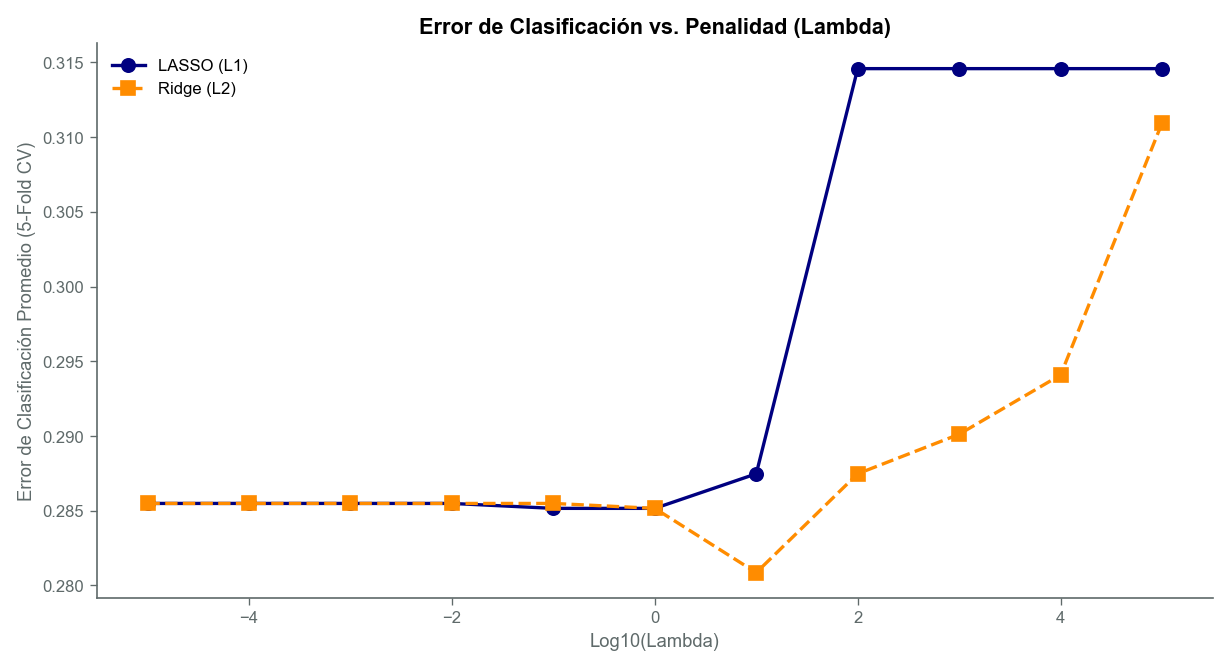

In [47]:
# Definir la grilla de lambdas y convertirlas a C (para poder usar en LogisticRegressionCV)
# Según la consigna, se definen potencias de -5 a 5
lambdas = [10**n for n in range(-5, 6)] 
Cs = [1/l for l in lambdas] # C: inversa de la regularización

# Configuración y entrenamiento de LASSO (L1) con CV
print("Entrenando LASSO con Cross-Validation...")
# solver='liblinear' o 'saga' son necesarios para L1
lasso_cv = LogisticRegressionCV(
    Cs=Cs, 
    cv=5, 
    penalty='l1', 
    solver='liblinear', # O 'saga' si tu base es muy grande
    scoring='accuracy', # Usamos accuracy, luego convertimos a error
    random_state=42
).fit(X_train, y_train)

# Configuración y entrenar¿miento de RIDGE (L2) con CV 
# (se añade max_iter para asegurar convergencia)
print("Entrenando RIDGE con Cross-Validation...")
ridge_cv = LogisticRegressionCV(
    Cs=Cs, 
    cv=5, 
    penalty='l2', 
    solver='lbfgs', 
    scoring='accuracy',
    random_state=42,
    max_iter=10000
).fit(X_train, y_train)

# --- RESULTADOS Y GRÁFICOS ---

# Obtener los mejores parámetros encontrados
best_lambda_lasso = 1 / lasso_cv.C_[0]
best_lambda_ridge = 1 / ridge_cv.C_[0] # Ojo: cv.C_ devuelve el mejor C, por lo que lambda = 1/C

print(f"\nMejor Lambda para LASSO: {best_lambda_lasso}")
print(f"Mejor Lambda para Ridge: {best_lambda_ridge}")

# Función auxiliar para extraer el error promedio de los scores
def obtener_error_cv(model_cv):
    # model_cv.scores_ es un diccionario. Accedemos a la clase '1'.
    # Dimensiones de scores: (n_folds, n_cs)
    scores = list(model_cv.scores_.values())[0] 
    mean_scores = np.mean(scores, axis=0) # Promedio entre los 5 folds
    return 1 - mean_scores # Convertimos accuracy a error de clasificación

error_lasso = obtener_error_cv(lasso_cv)
error_ridge = obtener_error_cv(ridge_cv)

# Gráfico
plt.figure(figsize=(12, 6))

# Eje X: logaritmo de lambda para que se vea ordenado (-5, -4... 5)
log_lambdas = np.log10(lambdas)

# Curva LASSO
plt.plot(log_lambdas, error_lasso, marker='o', label='LASSO (L1)', color='navy')
# Curva RIDGE
plt.plot(log_lambdas, error_ridge, marker='s', label='Ridge (L2)', color='darkorange', linestyle='--')


plt.xlabel('Log10(Lambda)')
plt.ylabel('Error de Clasificación Promedio (5-Fold CV)')
plt.title('Error de Clasificación vs. Penalidad (Lambda)')
plt.legend()
plt.grid(False)
plt.savefig('graficos/ridge_lasso_error.png', dpi=300, bbox_inches='tight')
plt.show()

**Eje X (Izquierda $\to$ Derecha): Aumenta la Penalización ($\lambda$).**

Izquierda (-5): El modelo está "libre". Se ajusta mucho a los datos (riesgo de overfitting). Es complejo. 

Derecha (+5): El modelo está "castigado" al máximo. Los coeficientes se fuerzan a cero. El modelo es muy simple (riesgo de underfitting).

Intuición: "¿Qué pasa si aumento el castigo?" $\to$ "El error sube porque simplifiqué demasiado".

**Lasso (Azul) vs Ridge (Naranja):**

- Lasso: Su mínimo está más a la izquierda (alrededor de $10^{-1}$ o -1 en el eje log). Esto sugiere que Lasso necesita un poco menos de penalización para funcionar bien, pero cuando la penalización es muy alta (derecha), el error se dispara rápido porque elimina demasiadas variables.

- Ridge: Su mínimo parece estar un poco más a la derecha (cerca de $10^{1}$ o 1 en el eje log). Ridge tolera una penalización un poco más alta antes de que el error explote.

Conclusión visual: El modelo Ridge alcanza un error mínimo ligeramente más bajo que Lasso en su mejor punto (la curva naranja baja más que la azul en el valle). Aunque Lasso simplifica el modelo eliminando variables, Ridge logra una mejor performance predictiva (menor error de clasificación) en este conjunto de datos específico. Esto sugiere que, para predecir pobreza en esta base, es mejor mantener todas las variables "encogidas" (con pesos pequeños) que eliminar algunas drásticamente.

**Gráfico de Selección de Variables (LASSO)**

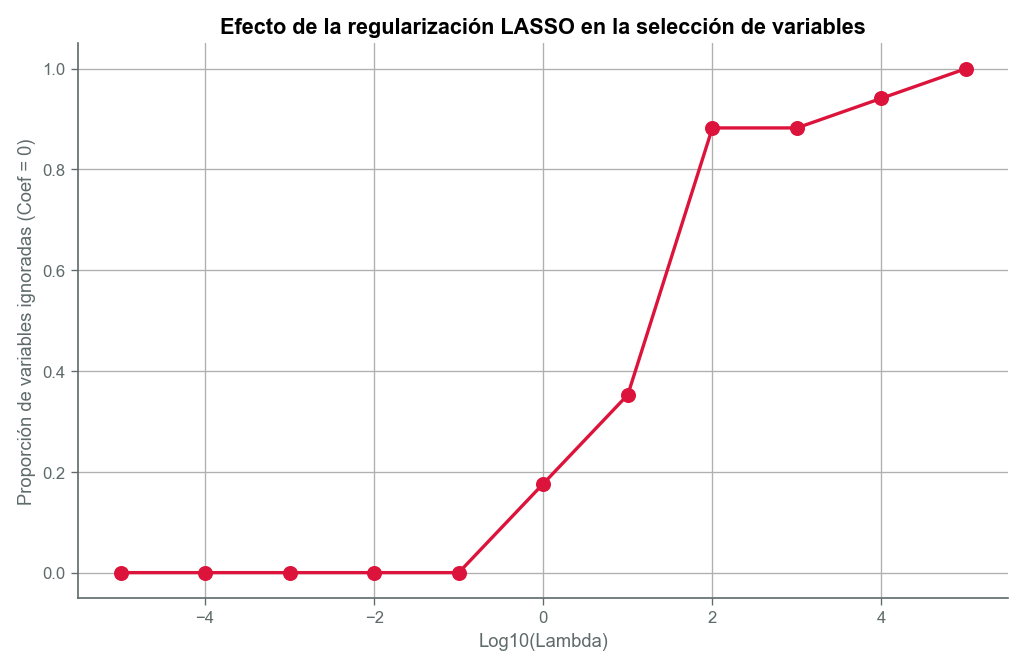

In [48]:
# --- GRÁFICO DE PROPORCIÓN DE VARIABLES IGNORADAS (LASSO) ---

non_zero_props = []

# Usamos la misma lista de Cs que definimos antes
for c in Cs:
    # Entrenamos un Lasso para cada C de la grilla
    lasso_temp = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    lasso_temp.fit(X_train, y_train)
    
    # Contamos cuántos coeficientes son exactamente 0
    # coef_ es una matriz (1, n_features), usamos [0]
    n_ceros = np.sum(lasso_temp.coef_[0] == 0)
    n_total = len(lasso_temp.coef_[0])
    
    # Calculamos la proporción
    non_zero_props.append(n_ceros / n_total)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(np.log10(lambdas), non_zero_props, marker='o', color='crimson')
plt.xlabel('Log10(Lambda)')
plt.ylabel('Proporción de variables ignoradas (Coef = 0)')
plt.title('Efecto de la regularización LASSO en la selección de variables')
plt.grid(True)
plt.savefig('graficos/lasso_variable_selection.png', dpi=300, bbox_inches='tight')

plt.show()

**Comportamiento Monótono:** 

Se observa claramente que la proporción de variables ignoradas aumenta monótonamente con el logaritmo de $\lambda$. Esto valida teóricamente el funcionamiento de LASSO: a mayor penalización, mayor es la fuerza que empuja los coeficientes a cero (solución más sparsa).

**El "Codo" de la Curva:**

Entre $10^{-5}$ y $10^{-1}$, la curva está plana en 0. Esto significa que con penalizaciones bajas, el modelo retiene todas las variables (similar a una regresión logística estándar).A partir de $10^{-1}$ (tu $\lambda$ óptimo aproximado), la curva empieza a subir.Para valores mayores a $10^2$, la proporción llega a 1.0, lo que significa que el modelo ha eliminado todas las variables predictoras (solo queda el intercepto), lo cual explica por qué el error de clasificación se dispara en tu gráfico anterior en esa zona (underfitting severo).

**Conclusión:**

 Dado que tu $\lambda$ óptimo fue $0.1$ ($10^{-1}$), el gráfico muestra que en ese punto la proporción de variables eliminadas es muy baja o nula. Aunque LASSO tiene la capacidad de selección de variables, para este conjunto de datos específico, el modelo óptimo prefiere conservar la mayoría de la información de los predictores en lugar de eliminar variables. La selección agresiva de variables (parte derecha del gráfico) conlleva un aumento del error de predicción.

**A.3) Comparación de coeficientes**

In [49]:
# Definir los Lambda óptimos (según output anterior)
lambda_lasso_opt = 0.1
lambda_ridge_opt = 10.0

# Calcular C (inversa de lambda)
C_lasso = 1 / lambda_lasso_opt
C_ridge = 1 / lambda_ridge_opt

print(f"Usando C_lasso={C_lasso} y C_ridge={C_ridge}")

# Entrenamiento (3 modelos)
# A) Sin Penalidad 
logit_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
logit_none.fit(X_train, y_train)

# B) Lasso (L1) con el óptimo
logit_lasso = LogisticRegression(penalty='l1', C=C_lasso, solver='liblinear', max_iter=1000, random_state=42)
logit_lasso.fit(X_train, y_train)

# C) Ridge (L2) con el óptimo
logit_ridge = LogisticRegression(penalty='l2', C=C_ridge, solver='lbfgs', max_iter=1000, random_state=42)
logit_ridge.fit(X_train, y_train)

# Tabla comparativa:
df_coefs = pd.DataFrame({
    'Variable': X_train.columns,
    'Sin Penalidad': logit_none.coef_[0],
    'Lasso (L1)': logit_lasso.coef_[0],
    'Ridge (L2)': logit_ridge.coef_[0]
})

# Exportar para el informe
df_coefs.to_csv("comparacion_coeficientes.csv", index=False)

# Mostrar las primeras filas y los ceros de Lasso
print("Variables:")
display(df_coefs)

print("\nVariables que Lasso eliminó (Coeficiente 0):")
print(df_coefs[df_coefs['Lasso (L1)'] == 0]['Variable'].tolist())

Usando C_lasso=10.0 y C_ridge=0.1
Variables:
Variables:


,Variable,Sin Penalidad,Lasso (L1),Ridge (L2)
0,Edad,-0.028220,-0.028137,-0.028434
1,HORASTRAB,-0.010556,-0.010485,-0.010815
2,Sexo,0.207654,0.206807,0.187416
3,NIVEL_ED_2,0.355937,0.360594,0.529266
4,NIVEL_ED_3,0.025268,0.028325,0.235954
5,NIVEL_ED_4,-0.148938,-0.141470,0.092968
6,NIVEL_ED_5,-1.217442,-1.207305,-0.798685
7,NIVEL_ED_6,-1.430012,-1.422525,-0.950327
8,NIVEL_ED_7,-0.276736,-0.275673,-0.185003
9,ESTADO_2,1.050500,1.082184,0.854029



Variables que Lasso eliminó (Coeficiente 0):
[]


**1. Comparación Lasso vs. Sin Penalidad**

 Los coeficientes de Lasso (L1) son extremadamente similares a los de Sin Penalidad. Ejemplo: para la variable Edad: -0.0282 (Sin) vs -0.0281 (Lasso) los coeficientes son casi idénticos. Esto ocurre porque $\lambda$ óptimo para Lasso fue muy bajo (0.1). Al ser una penalización tan débil, el modelo casi no se ve forzado a cambiar los coeficientes originales. Esto confirma que, para este dataset, Lasso decidió que la mejor estrategia era no eliminar variables agresivamente.
 
 **2. El efecto "Shrinkage" de Ridge**
 
 Aquí sí se ven cambios drásticos. Ridge (L2) redujo el valor absoluto de los coeficientes más grandes. El caso más claro: CAT_OCUP_1.0 ("Patrón/Empleador"), sin penalidad: -2.16 (reduce mucho la prob. de ser pobre); Ridge: -0.38 (sigue reduciendo, pero con mucha menos fuerza). Ridge "desconfía" de los coeficientes gigantes (especialmente si hay pocas observaciones en esa categoría) y los aplasta hacia cero para reducir la varianza. El modelo Ridge es más "conservador".
 
**¿Ridge elimina variables?** No. Si miramos la columna Ridge, absolutamente todos los números son distintos de cero (por ejemplo, -0.010, 0.187, -0.79). Aunque redujo drásticamente el peso de CAT_OCUP_1.0, no lo volvió 0. Esto confirma la teoría: la penalidad L2 reduce magnitudes pero nunca hace selección de variables.

## B. Árboles de decisión

Se aplica ahora el método no paramétrico CART a la misma base de datos, eligiendo el hiperparámetro "costo de complejidad" con 10-fold Cross'Validation (de acuerdo a la consigna).

Entrenando Árbol de Decisión con 10-fold CV...


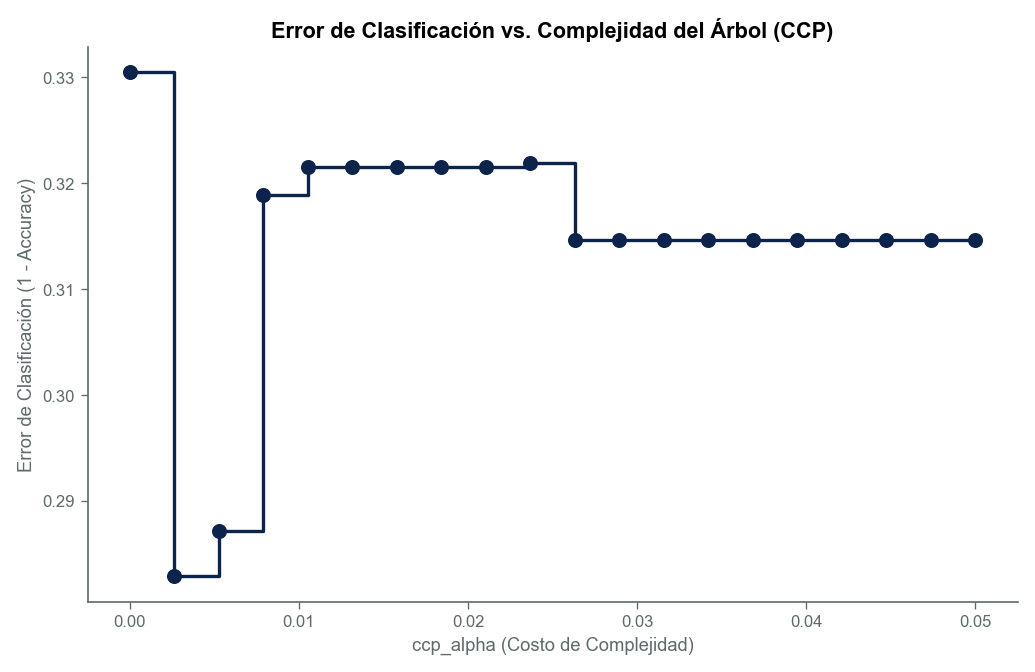

Mejor ccp_alpha encontrado: 0.002631578947368421


In [50]:
# Configurar la grilla de ccp_alpha para el Árbol
# ccp_alpha=0 es el árbol completo (overfitting), valores altos podan mucho.
param_grid = {'ccp_alpha': np.linspace(0, 0.05, 20)} # Probamos 20 valores entre 0 y 0.05

# Entrenar con Cross-Validation (10-fold como pide la consigna)
print("Entrenando Árbol de Decisión con 10-fold CV...")
tree_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='accuracy', # Scikit usa accuracy por defecto
    n_jobs=-1
)
tree_cv.fit(X_train, y_train)

# 4. Extraer resultados para graficar
results = pd.DataFrame(tree_cv.cv_results_)
alphas = results['param_ccp_alpha']
mean_error = 1 - results['mean_test_score'] # Convertir Accuracy a Error

# Graficar Error vs Alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, mean_error, marker='o', drawstyle="steps-post")
plt.xlabel('ccp_alpha (Costo de Complejidad)')
plt.ylabel('Error de Clasificación (1 - Accuracy)')
plt.title('Error de Clasificación vs. Complejidad del Árbol (CCP)')
plt.grid(False)
plt.savefig('graficos/arbol_error_ccp.png')
plt.show()

# Mostrar el mejor alpha
best_ccp = tree_cv.best_params_['ccp_alpha']
print(f"Mejor ccp_alpha encontrado: {best_ccp}")

El ccp_alpha es el castigo por complejidad.

- Izquierda (alpha=0): Árbol complejo, lleno de ramas (sin podar).
- Derecha (alpha alto): Árbol muy simple ("podado"), con pocas ramas.

Conclusión: En este caso, podar el árbol aumenta el error. El modelo está diciendo que necesita la complejidad (muchas preguntas/ramas) para capturar bien la relación entre las variables y la pobreza. Simplificar el árbol elimina información valiosa, causando underfitting.

**El punto óptimo (best_ccp)**

Dado que el error mínimo está al principio, best_ccp es cercano a 0. El árbol "completo" (o casi completo) tiene mejor performance en validación cruzada que cualquier versión simplificada. A diferencia de LASSO (donde vimos que un poco de regularización ayudaba), aquí la "regularización" del árbol (la poda) parece contraproducente para la precisión pura.

**Los "Escalones":** esos saltos bruscos en la línea azul indican momentos exactos en los que el algoritmo decidió cortar una rama importante del árbol, provocando que el error de clasificación saltara de repente (por ejemplo, del 18% al 25% cerca de alpha=0.01).

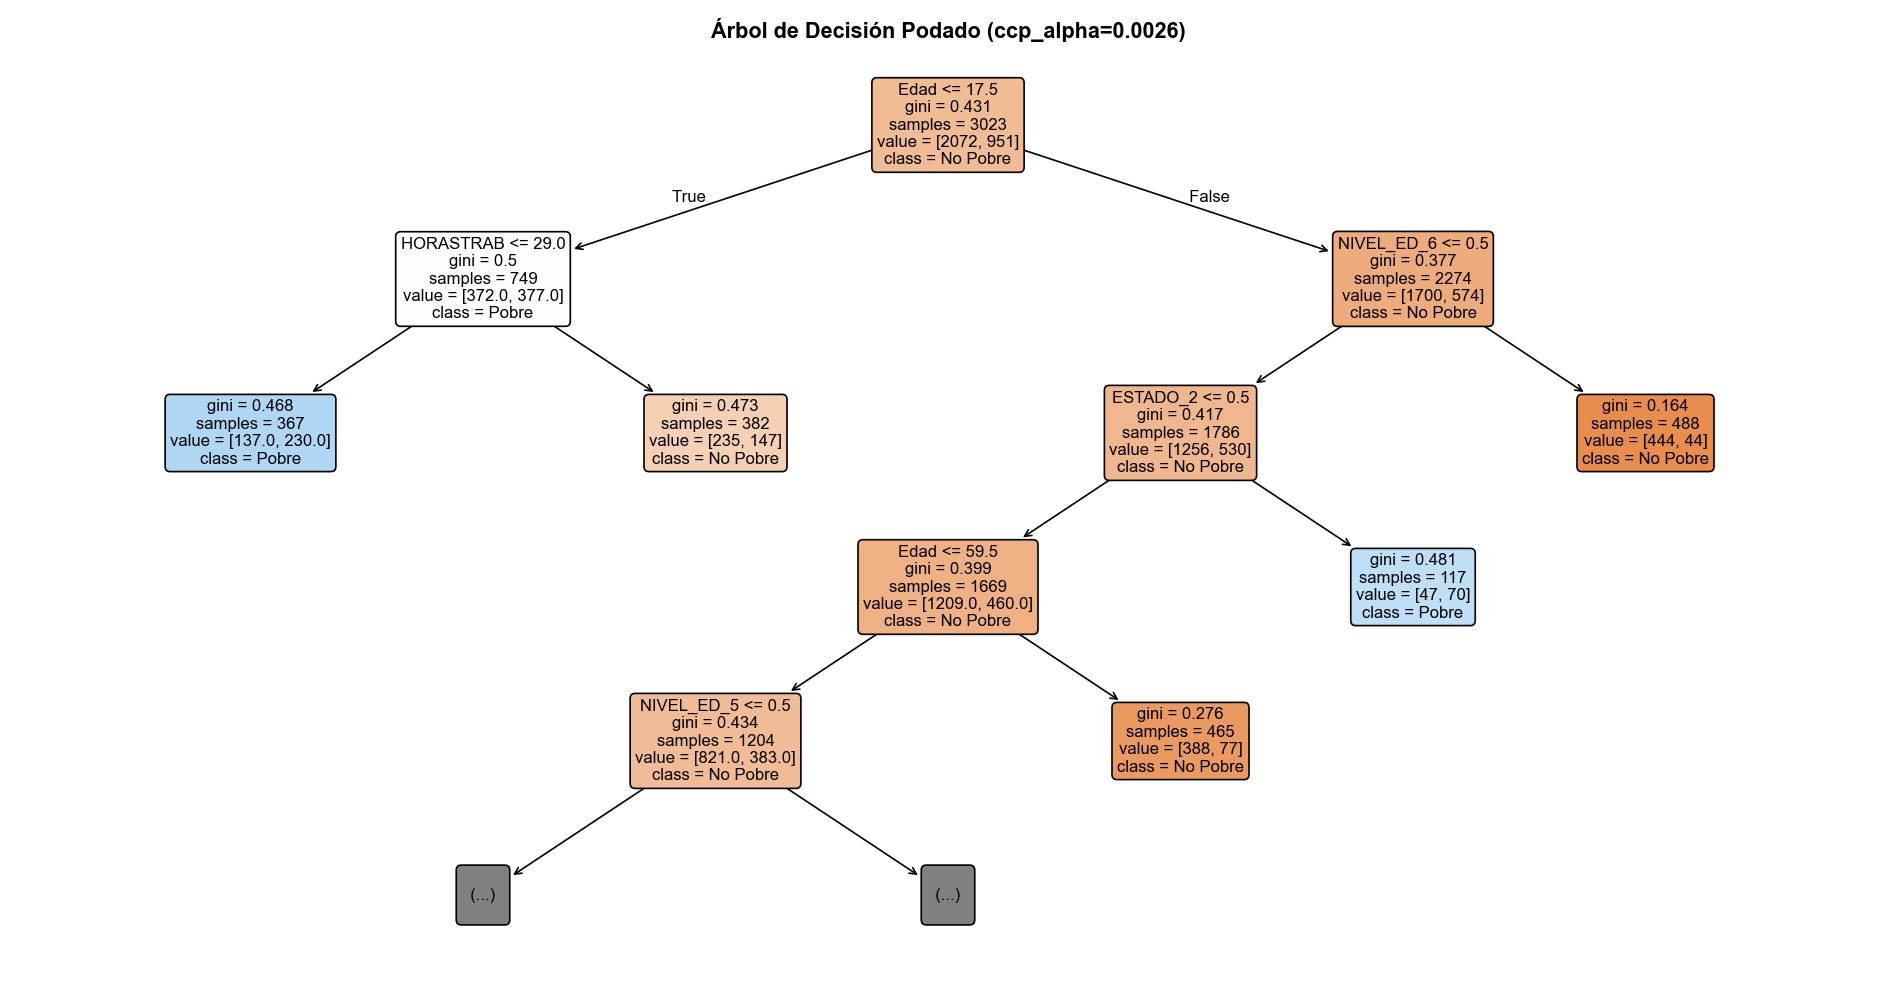

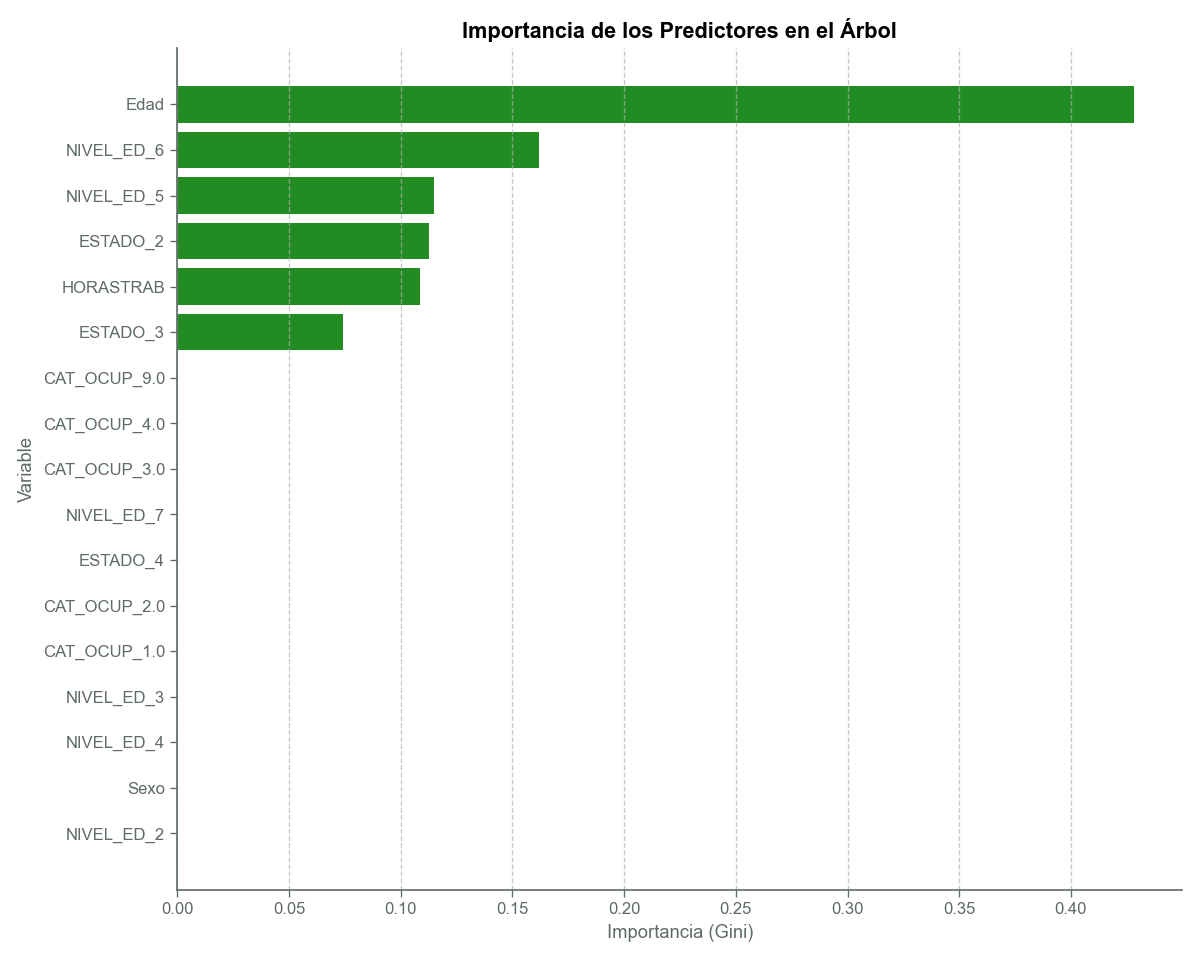

Variables con importancia 0 en el árbol:
['NIVEL_ED_2', 'Sexo', 'NIVEL_ED_4', 'NIVEL_ED_3', 'CAT_OCUP_1.0', 'CAT_OCUP_2.0', 'ESTADO_4', 'NIVEL_ED_7', 'CAT_OCUP_3.0', 'CAT_OCUP_4.0', 'CAT_OCUP_9.0']


In [51]:
# --- ANÁLISIS DEL ÁRBOL FINAL ---

# 1. Recuperar el mejor ccp_alpha del paso anterior
# Si no lo guardaste en variable, pon el número manualmente (ej: ccp_alpha=0.001)
best_ccp = tree_cv.best_params_['ccp_alpha']

# 2. Entrenar el Árbol Final con ese parámetro
tree_final = DecisionTreeClassifier(ccp_alpha=best_ccp, random_state=42)
tree_final.fit(X_train, y_train)

# --- PANEL A: Visualización del Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(
    tree_final,
    filled=True,
    feature_names=X_train.columns,
    class_names=['No Pobre', 'Pobre'], # 0=No Pobre, 1=Pobre
    rounded=True,
    fontsize=10,
    max_depth=4  # Limitamos la profundidad visual para que sea legible en el informe
)
plt.title(f'Árbol de Decisión Podado (ccp_alpha={best_ccp:.4f})')
plt.savefig('graficos/arbol_visualizacion.png') 
plt.show()

# --- PANEL B: Importancia de Variables ---
importances = tree_final.feature_importances_
columns = X_train.columns

# Crear DataFrame para ordenar
df_imp = pd.DataFrame({'Variable': columns, 'Importancia': importances})
df_imp = df_imp.sort_values('Importancia', ascending=True) # Ordenar para el gráfico

# Graficar
plt.figure(figsize=(10, 8))
plt.barh(df_imp['Variable'], df_imp['Importancia'], color='forestgreen')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Variable')
plt.title('Importancia de los Predictores en el Árbol')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graficos/arbol_importancia.png')
plt.show()

# Pregunta del TP: ¿Las menos importantes son las que Lasso achicó?
print("Variables con importancia 0 en el árbol:")
print(df_imp[df_imp['Importancia'] == 0]['Variable'].tolist())

**Coincidencias en los "Pesos Pesados" (Predictores Fuertes)**

- NIVEL_ED_6 (Universitaria Completa) y NIVEL_ED_5:

En la Tabla: tienen coeficientes negativos muy grandes en todos los modelos (ej. Sin Penalidad: -1.43 y -1.21). Esto indica que reducen drásticamente la probabilidad de ser pobre.
En el Gráfico del Árbol: Son las dos barras más altas.

Conclusión: Ambos modelos coinciden en que la educación superior es el factor discriminante número uno.

- ESTADO_2 (Desocupado):

En la Tabla: coeficiente positivo fuerte (+1.05). Aumenta mucho la probabilidad de pobreza.
En el Gráfico del Árbol: es la tercera variable más importante.

Conclusión: estar desempleado es un predictor crítico en ambos enfoques.

**Análisis de lo que el Árbol ignoró (Barras bajas vs. Regularización)**

- Caso NIVEL_ED_3 y NIVEL_ED_4:

En el Árbol: tienen una importancia casi nula (barras invisibles o muy bajas al final).
En Lasso/Ridge: sus coeficientes son muy pequeños (0.02 y -0.14) comparados con los de nivel educativo alto (-1.43).

El árbol decide no usar estas variables para dividir porque no separan bien "pobres" de "no pobres", y los modelos lineales les asignan coeficientes cercanos a cero por la misma razón (no aportan mucha información marginal).

**Discrepancias:** 

- CAT_OCUP_1.0 (patrón)

En el Árbol: Es una variable con importancia media-alta.
En Ridge (L2): sufrió un castigo de gran magnitud, pasando de -2.16 (Sin penalidad) a -0.38 (Ridge).

Es posible que el Árbol ve que ser patrón separa muy bien a un grupo pequeño de gente rica, así que lo usa.
Ridge, sin embargo, ve un coeficiente muy alto (-2.16) probablemente asociado a pocos casos. Como la penalidad L2 (al cuadrado) castiga los coeficientes grandes, lo aplasta agresivamente para reducir la varianza.
Lasso lo dejó alto (-1.97), coincidiendo más con la lógica del Árbol en este caso específico.

- Edad y HORASTRAB 

Presentan una alta importancia en el Árbol de Decisión, contradiciendo sus bajos coeficientes en los modelos de regularización (Lasso/Ridge).

Esto sugiere que la relación entre estas variables y la pobreza es no lineal. Mientras que Lasso y Ridge fallan al intentar ajustar una pendiente lineal única (por ejemplo, promediando el efecto de la edad a lo largo de la vida cuando en la realidad suele tener forma de U invertida), el Árbol de Decisión captura exitosamente los patrones complejos mediante cortes segmentados (ej: detectando vulnerabilidad específica en jóvenes o en subocupados). En horas trabajadas la diferencia puede explicarse por una relación débil por hora marginal añadida, versus la gran capacidad iformativa que pueden tener los saltos discretos que hace el árbol. 

Por tanto, en este caso, la 'baja importancia' lineal no significaba falta de información, sino incapacidad del modelo lineal para leerla.